In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv

from multipred.plotting import (analyze_attention_ROI, barplot_morey, plot_decoding_modalities,)
                                #plot_decoding_nvoxels)

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across modalities

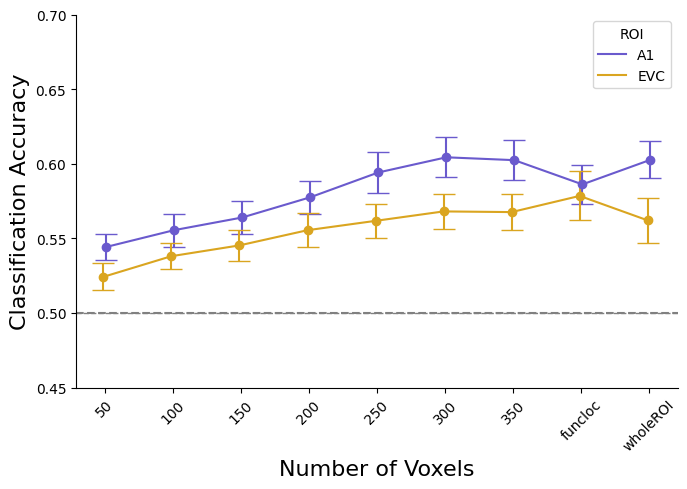


Summary of decoding accuracy statistics:
 n_voxels_label ROI  n_subjects  accuracy  t_value  p_value
             50 EVC          24    0.5242   2.6457   0.0144
             50  A1          24    0.5442   4.9531   0.0001
            100 EVC          24    0.5380   4.3604   0.0002
            100  A1          24    0.5555   5.0543   0.0001
            150 EVC          23    0.5453   4.4613   0.0002
            150  A1          23    0.5639   5.6240   0.0000
            200 EVC          23    0.5554   4.9510   0.0001
            200  A1          23    0.5775   6.9884   0.0000
            250 EVC          23    0.5617   5.5156   0.0000
            250  A1          23    0.5941   7.0055   0.0000
            300 EVC          23    0.5680   5.9351   0.0000
            300  A1          23    0.6043   7.7909   0.0000
            350 EVC          23    0.5676   5.7108   0.0000
            350  A1          23    0.6024   7.5192   0.0000
            400 EVC          24    0.5784   4.7737   0.000

In [3]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]

df_all, df_stats = plot_decoding_modalities(DATA_PATH, n_voxels_list)

# Show the summary of decoding results
print("\nSummary of decoding accuracy statistics:")
print(df_stats.round(4).to_string(index=False))

## Analyze specific ROIs

In [3]:
ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df["prob_predictions"] = np.where(df["prob_0"] < 0.5, 45, 135)
df["prob_correct"] = np.where(
    df["labels"] == df["prob_predictions"], 1, 0
)  # 1 if prob prediction is correct, 0 if not


### Attention * visual prediction

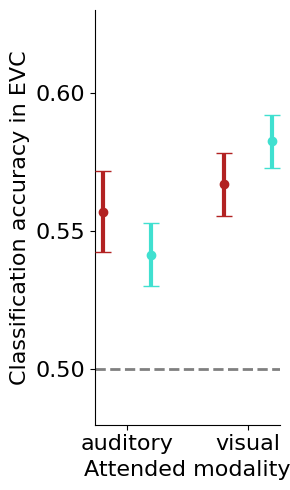

In [4]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
savefig = False
errorbar_style={"capsize": 6, "elinewidth": 3, "markersize": 6}

dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
fig, ax = plt.subplots(figsize=(3, 5))
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False, ax, legend=False, errorbar_style=errorbar_style, fontsize=16)
sns.despine()
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0.48, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--", linewidth=2)
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/MVPA/attention_pred_{ROI}.svg", dpi=300)
plt.show()

In [5]:
df[y].mean()

np.float64(0.5620166666666667)

In [6]:
df.groupby(["v_pred"])[y].mean()

v_pred
0    0.561987
1    0.562046
Name: correct, dtype: float64

In [5]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,1.613959e-02,1,24,1.613959e-02,3.725103,0.065501,0.065501,2.005266e-02,1.0
1,v_pred,8.506944e-08,1,24,8.506944e-08,0.000022,0.996300,0.996300,1.078575e-07,1.0
2,modality * v_pred,6.071007e-03,1,24,6.071007e-03,2.557319,0.122868,0.122868,7.638489e-03,1.0


In [8]:
pg.pairwise_tests(dv=y, within=[hue], subject=id, data=dat[dat["modality"]=="visual"], alternative="less", effsize="cohen")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen
0,v_pred,0,1,True,True,-1.251142,24.0,less,0.111471,0.847,-0.169413


In [9]:
pg.pairwise_tests(dv=y, within=[hue], subject=id, data=dat[dat["modality"]=="auditory"], alternative="greater", effsize="cohen")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen
0,v_pred,0,1,True,True,0.837512,24.0,greater,0.205284,0.579,0.174591


### Multimodal analyses

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotti

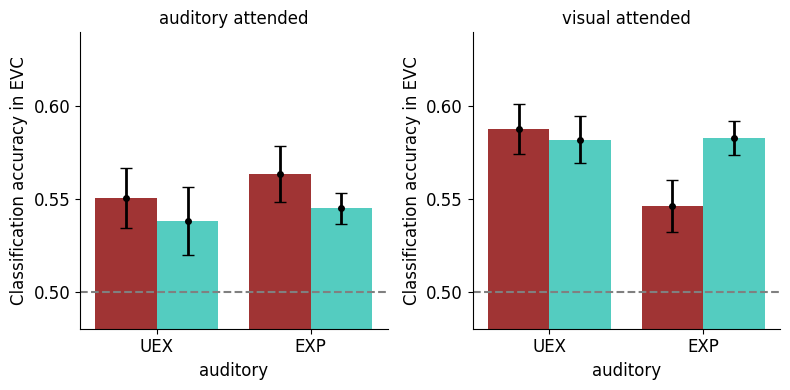

In [11]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = True
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[y].mean()

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, n_voxels, save_fig, ylim, yticks
)

In [12]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.002446,1,24,0.002446,0.518588,0.478400,0.478400,0.002533,1.0
1,auditory attended,1,v_pred,0.006026,1,24,0.006026,0.701427,0.410568,0.410568,0.006217,1.0
2,auditory attended,2,a_pred * v_pred,0.000249,1,24,0.000249,0.065792,0.799752,0.799752,0.000259,1.0
3,visual attended,0,a_pred,0.010396,1,24,0.010396,2.654435,0.116318,0.116318,0.010223,1.0
4,visual attended,1,v_pred,0.006117,1,24,0.006117,1.565357,0.222942,0.222942,0.006041,1.0
5,visual attended,2,a_pred * v_pred,0.011351,1,24,0.011351,2.895391,0.101755,0.101755,0.011153,1.0


In [13]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,auditory attended,0,a_pred,-,0,1,True,True,-0.720131,24.0,two-sided,0.478400,NaN,NaN,0.267,-0.118749
1,auditory attended,1,v_pred,-,0,1,True,True,0.837512,24.0,two-sided,0.410568,NaN,NaN,0.29,0.174591
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,0.457677,24.0,two-sided,0.651301,0.651301,fdr_bh,0.232,0.106763
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,1.157871,24.0,two-sided,0.258310,0.516620,fdr_bh,0.384,0.229097
4,visual attended,0,a_pred,-,0,1,True,True,1.629244,24.0,two-sided,0.116318,NaN,NaN,0.671,0.220832
5,visual attended,1,v_pred,-,0,1,True,True,-1.251142,24.0,two-sided,0.222942,NaN,NaN,0.423,-0.169413
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,0.299249,24.0,two-sided,0.767326,0.767326,fdr_bh,0.22,0.050743
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-2.258579,24.0,two-sided,0.033274,0.066549,fdr_bh,1.773,-0.400871


In [14]:
df_grouped.groupby(["modality", "a_pred", "v_pred"])[y].mean().unstack()

v_pred                 0         1
modality a_pred                   
auditory 0       0.55055  0.538183
         1       0.56360  0.544917
visual   0       0.58775  0.582083
         1       0.54605  0.583000

In [18]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=df_grouped[(df_grouped["modality"]=="visual")], alternative="less", effsize="cohen", padjust="fdr_bh")

,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,a_pred,-,0,1,True,True,1.629244,24.0,less,0.941841,NaN,NaN,0.745,0.220832
1,v_pred,-,0,1,True,True,-1.251142,24.0,less,0.111471,NaN,NaN,0.847,-0.169413
2,a_pred * v_pred,0,0,1,True,True,0.299249,24.0,less,0.616337,0.616337,fdr_bh,0.439,0.050743
3,a_pred * v_pred,1,0,1,True,True,-2.258579,24.0,less,0.016637,0.033274,fdr_bh,3.546,-0.400871


In [17]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=df_grouped[(df_grouped["modality"]=="auditory")], alternative="greater", effsize="cohen", padjust="fdr_bh")

,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,a_pred,-,0,1,True,True,-0.720131,24.0,greater,0.760800,NaN,NaN,0.534,-0.118749
1,v_pred,-,0,1,True,True,0.837512,24.0,greater,0.205284,NaN,NaN,0.579,0.174591
2,a_pred * v_pred,0,0,1,True,True,0.457677,24.0,greater,0.325650,0.32565,fdr_bh,0.464,0.106763
3,a_pred * v_pred,1,0,1,True,True,1.157871,24.0,greater,0.129155,0.25831,fdr_bh,0.768,0.229097


### Multiple comparisons

In [19]:
import pingouin as pg
import pandas as pd
from statsmodels.stats.multitest import multipletests

results = []
df_visual = df_grouped[df_grouped['modality'] == 'visual']
for a in df_visual['a_pred'].unique():
        subset = df_visual[(df_visual['a_pred'] == a)]
        res = pg.pairwise_tests(dv=y, within='v_pred', subject=id, data=subset,
                                padjust='fdr_bh', effsize='cohen', alternative="less")
        res['a_pred'] = a
        results.append(res)

simple_effects_df = pd.concat(results, ignore_index=True)

# Extract p-values from your combined simple effects dataframe
raw_pvals = simple_effects_df['p-unc']

# Apply FDR correction
reject, pvals_corr, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

# Add corrected results back into the dataframe
simple_effects_df['p-corr'] = pvals_corr
simple_effects_df['significant'] = reject
simple_effects_df

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen,a_pred,p-corr,significant
0,v_pred,0,1,True,True,0.299249,24.0,less,0.616337,0.439,0.050743,0,0.616337,False
1,v_pred,0,1,True,True,-2.258579,24.0,less,0.016637,3.546,-0.400871,1,0.033274,True


In [20]:
results = []
df_auditory = df_grouped[df_grouped['modality'] == 'auditory']
for a in df_auditory['a_pred'].unique():
        subset = df_auditory[(df_auditory['a_pred'] == a)]
        res = pg.pairwise_tests(dv=y, within='v_pred', subject=id, data=subset,
                                padjust='fdr_bh', effsize='cohen', alternative="greater")
        res['a_pred'] = a
        results.append(res)

simple_effects_df = pd.concat(results, ignore_index=True)

# Extract p-values from your combined simple effects dataframe
raw_pvals = simple_effects_df['p-unc']

# Apply FDR correction
reject, pvals_corr, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

# Add corrected results back into the dataframe
simple_effects_df['p-corr'] = pvals_corr
simple_effects_df['significant'] = reject
simple_effects_df

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen,a_pred,p-corr,significant
0,v_pred,0,1,True,True,0.457677,24.0,greater,0.325650,0.464,0.106763,0,0.32565,False
1,v_pred,0,1,True,True,1.157871,24.0,greater,0.129155,0.768,0.229097,1,0.25831,False
